STAGE 1: K-MEANS CLASSIFICATION
\n[1] Loading data...
✓ Loaded 1200000 records with 21 features
\n[2] Handling missing values...
✓ Missing values handled
\n[3] Encoding categorical features...
✓ Categorical features encoded
\n[4] Selecting risk features for clustering...
✓ Selected 10 features
\n[5] Standardizing features...
✓ Features standardized
\n[6] Running K-Means clustering...
✓ K-Means clustering complete (k=3)
\n[7] Analyzing clusters...
   Cluster 0: Risk Score = 24.96
   Cluster 1: Risk Score = 54.95
   Cluster 2: Risk Score = 40.77
\n[8] Mapping clusters to risk categories...
\n✓ Risk Category Mapping:
   Cluster 0 → Low Risk (Score: 24.96)
   Cluster 2 → Medium Risk (Score: 40.77)
   Cluster 1 → High Risk (Score: 54.95)
\n================================================================================
CLASSIFICATION RESULTS
\nRisk Distribution:
   Low Risk       : 502261 customers (41.9%)
   Medium Risk    : 192321 customers (16.0%)
   High Risk      : 505418 customers (42

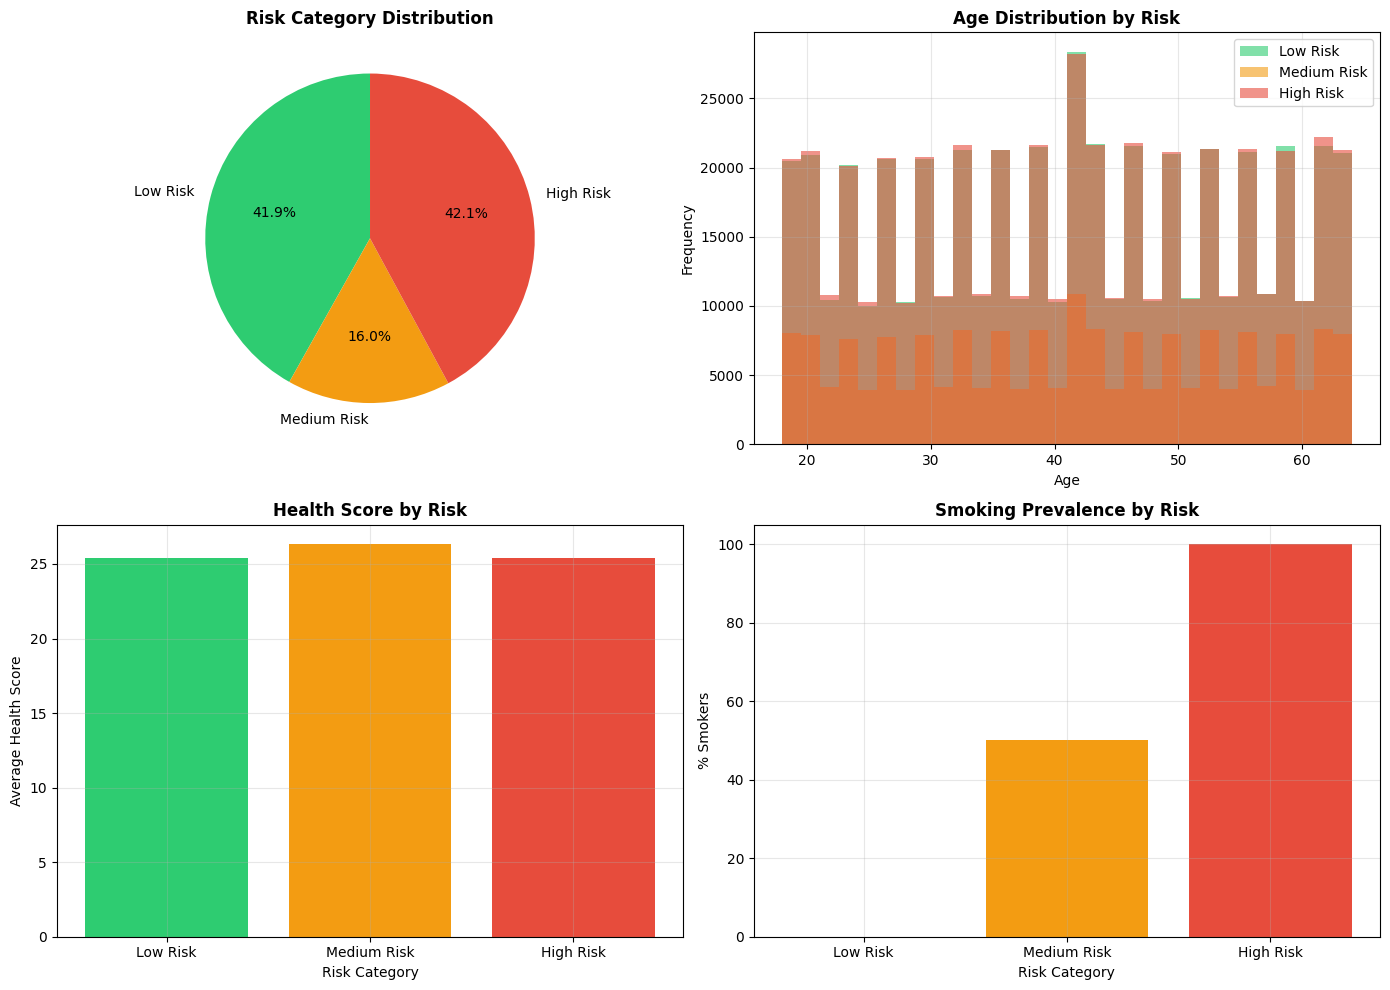

\n================================================================================
✓ STAGE 1 COMPLETE: Risk Classification Done!
\nNext: Run Cell 2 for Premium Prediction


In [2]:
# ============================================================================
# CELL 1: K-MEANS CLASSIFICATION - RISK SEGMENTATION
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("STAGE 1: K-MEANS CLASSIFICATION")
print("="*80)

# ----------------------------------------------------------------------------
# 1. LOAD DATA
# ----------------------------------------------------------------------------
print("\\n[1] Loading data...")
df = pd.read_csv('../data/train.csv')
print(f"✓ Loaded {len(df)} records with {len(df.columns)} features")

# Create working copy
df_work = df.copy()

# ----------------------------------------------------------------------------
# 2. HANDLE MISSING VALUES
# ----------------------------------------------------------------------------
print("\\n[2] Handling missing values...")

# Fill numeric columns with median
for col in df_work.select_dtypes(include=[np.number]).columns:
    df_work[col].fillna(df_work[col].median(), inplace=True)

# Fill categorical columns with mode
for col in df_work.select_dtypes(include=['object']).columns:
    mode_val = df_work[col].mode()[0] if not df_work[col].mode().empty else 'Unknown'
    df_work[col].fillna(mode_val, inplace=True)

print("✓ Missing values handled")

# ----------------------------------------------------------------------------
# 3. ENCODE CATEGORICAL FEATURES FOR CLUSTERING
# ----------------------------------------------------------------------------
print("\\n[3] Encoding categorical features...")

# Smoking Status: Yes=1, No=0
df_work['Smoking_Encoded'] = (df_work['Smoking Status'] == 'Yes').astype(int)

# Exercise Frequency: Daily=3, Weekly=2, Monthly=1, Rarely=0
exercise_map = {'Daily': 3, 'Weekly': 2, 'Monthly': 1, 'Rarely': 0}
df_work['Exercise_Encoded'] = df_work['Exercise Frequency'].map(
    lambda x: exercise_map.get(x, 1) if pd.notna(x) else 1
)

print("✓ Categorical features encoded")

# ----------------------------------------------------------------------------
# 4. SELECT FEATURES FOR CLUSTERING
# ----------------------------------------------------------------------------
print("\\n[4] Selecting risk features for clustering...")

# 10 key risk features
cluster_features = [
    'Age',
    'Annual Income',
    'Health Score',
    'Previous Claims',
    'Vehicle Age',
    'Credit Score',
    'Insurance Duration',
    'Number of Dependents',
    'Smoking_Encoded',
    'Exercise_Encoded'
]

X_cluster = df_work[cluster_features].copy()
print(f"✓ Selected {len(cluster_features)} features")

# ----------------------------------------------------------------------------
# 5. STANDARDIZE FEATURES
# ----------------------------------------------------------------------------
print("\\n[5] Standardizing features...")
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)
print("✓ Features standardized")

# ----------------------------------------------------------------------------
# 6. APPLY K-MEANS CLUSTERING
# ----------------------------------------------------------------------------
print("\\n[6] Running K-Means clustering...")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10, max_iter=300)
df_work['Cluster'] = kmeans.fit_predict(X_cluster_scaled)
print("✓ K-Means clustering complete (k=3)")

# ----------------------------------------------------------------------------
# 7. ANALYZE CLUSTERS TO MAP TO RISK LEVELS
# ----------------------------------------------------------------------------
print("\\n[7] Analyzing clusters...")

# Calculate risk score for each cluster
cluster_risk_scores = {}

for cluster in range(3):
    cluster_data = df_work[df_work['Cluster'] == cluster]
    
    # Composite risk score (higher = more risky)
    risk_score = (
        cluster_data['Age'].mean() * 0.15 +
        cluster_data['Smoking_Encoded'].mean() * 100 * 0.30 +
        cluster_data['Previous Claims'].mean() * 25 * 0.20 +
        (100 - cluster_data['Health Score'].mean()) * 0.15 +
        (1000 - cluster_data['Credit Score'].mean()) * 0.02 * 0.10 +
        cluster_data['Vehicle Age'].mean() * 2 * 0.10
    )
    
    cluster_risk_scores[cluster] = risk_score
    print(f"   Cluster {cluster}: Risk Score = {risk_score:.2f}")

# ----------------------------------------------------------------------------
# 8. MAP CLUSTERS TO RISK CATEGORIES
# ----------------------------------------------------------------------------
print("\\n[8] Mapping clusters to risk categories...")

# Sort clusters by risk score
sorted_clusters = sorted(cluster_risk_scores.items(), key=lambda x: x[1])

# Map: lowest risk score = Low Risk, highest = High Risk
risk_mapping = {
    sorted_clusters[0][0]: 0,  # Low Risk
    sorted_clusters[1][0]: 1,  # Medium Risk
    sorted_clusters[2][0]: 2   # High Risk
}

# Apply mapping
df_work['Risk_Category'] = df_work['Cluster'].map(risk_mapping)

# Labels for display
risk_labels = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}
df_work['Risk_Label'] = df_work['Risk_Category'].map(risk_labels)

print("\\n✓ Risk Category Mapping:")
for orig_cluster, risk_cat in risk_mapping.items():
    score = cluster_risk_scores[orig_cluster]
    print(f"   Cluster {orig_cluster} → {risk_labels[risk_cat]} (Score: {score:.2f})")

# ----------------------------------------------------------------------------
# 9. DISPLAY CLASSIFICATION RESULTS
# ----------------------------------------------------------------------------
print("\\n" + "="*80)
print("CLASSIFICATION RESULTS")
print("="*80)

# Risk distribution
print("\\nRisk Distribution:")
for risk_cat in [0, 1, 2]:
    count = len(df_work[df_work['Risk_Category'] == risk_cat])
    pct = count / len(df_work) * 100
    print(f"   {risk_labels[risk_cat]:15s}: {count} customers ({pct:.1f}%)")

# Show summary statistics by risk category
print("\\nRisk Category Summary Statistics:")
summary_stats = df_work.groupby('Risk_Label').agg({
    'Age': 'mean',
    'Health Score': 'mean',
    'Smoking_Encoded': lambda x: (x == 1).sum() / len(x) * 100,
    'Previous Claims': 'mean'
}).round(2)
summary_stats.columns = ['Avg Age', 'Avg Health Score', '% Smokers', 'Avg Claims']
print(summary_stats)

# ----------------------------------------------------------------------------
# 10. VISUALIZE CLUSTERS
# ----------------------------------------------------------------------------
print("\\n[10] Creating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
risk_colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}

# Plot 1: Risk Distribution
ax = axes[0, 0]
risk_counts = df_work['Risk_Category'].value_counts().sort_index()
colors = [risk_colors[i] for i in risk_counts.index]
ax.pie(risk_counts, labels=[risk_labels[i] for i in risk_counts.index],
       autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Risk Category Distribution', fontweight='bold', fontsize=12)

# Plot 2: Age by Risk
ax = axes[0, 1]
for risk_cat in [0, 1, 2]:
    data = df_work[df_work['Risk_Category'] == risk_cat]['Age']
    ax.hist(data, bins=30, alpha=0.6, label=risk_labels[risk_cat],
            color=risk_colors[risk_cat])
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.set_title('Age Distribution by Risk', fontweight='bold', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Health Score by Risk
ax = axes[1, 0]
health_avg = df_work.groupby('Risk_Category')['Health Score'].mean()
ax.bar([0, 1, 2], health_avg, color=[risk_colors[i] for i in [0, 1, 2]])
ax.set_xlabel('Risk Category')
ax.set_ylabel('Average Health Score')
ax.set_title('Health Score by Risk', fontweight='bold', fontsize=12)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels([risk_labels[i] for i in [0, 1, 2]])
ax.grid(True, alpha=0.3)

# Plot 4: Smoking by Risk
ax = axes[1, 1]
smoking_pct = df_work.groupby('Risk_Category')['Smoking_Encoded'].mean() * 100
ax.bar([0, 1, 2], smoking_pct, color=[risk_colors[i] for i in [0, 1, 2]])
ax.set_xlabel('Risk Category')
ax.set_ylabel('% Smokers')
ax.set_title('Smoking Prevalence by Risk', fontweight='bold', fontsize=12)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels([risk_labels[i] for i in [0, 1, 2]])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('risk_classification_results.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved: risk_classification_results.png")
plt.show()

print("\\n" + "="*80)
print("✓ STAGE 1 COMPLETE: Risk Classification Done!")
print("="*80)
print("\\nNext: Run Cell 2 for Premium Prediction")

STAGE 2: PREMIUM PREDICTION
\n[1] Encoding all features for prediction...
✓ All features encoded
\n[2] Generating correct premium labels...
   Calculating correct premiums (this may take a moment)...
✓ Generated correct premiums
   Range: $307.72 - $7092.94
   Mean: $1563.67
\n[3] Preparing features for ML model...
✓ Feature matrix: (1200000, 18)
✓ Features include Risk_Category from clustering
✓ Total features: 18
\n[4] Splitting data for training...
✓ Training set: 960,000 samples
✓ Test set: 240,000 samples
\n[5] Training ML models...
\n   Training Random Forest...
   RMSE: $109.65
   MAE:  $71.94
   R²:   0.9829
\n   Training Gradient Boosting...
   RMSE: $26.34
   MAE:  $16.92
   R²:   0.9990
\n✓ Best Model: Gradient Boosting
\n[6] Predicting premiums for all customers...
   (This may take a moment with 1.2M records...)
✓ Predictions complete!
\n[7] Comparing predictions with old premiums...
\n================================================================================
PREMIUM

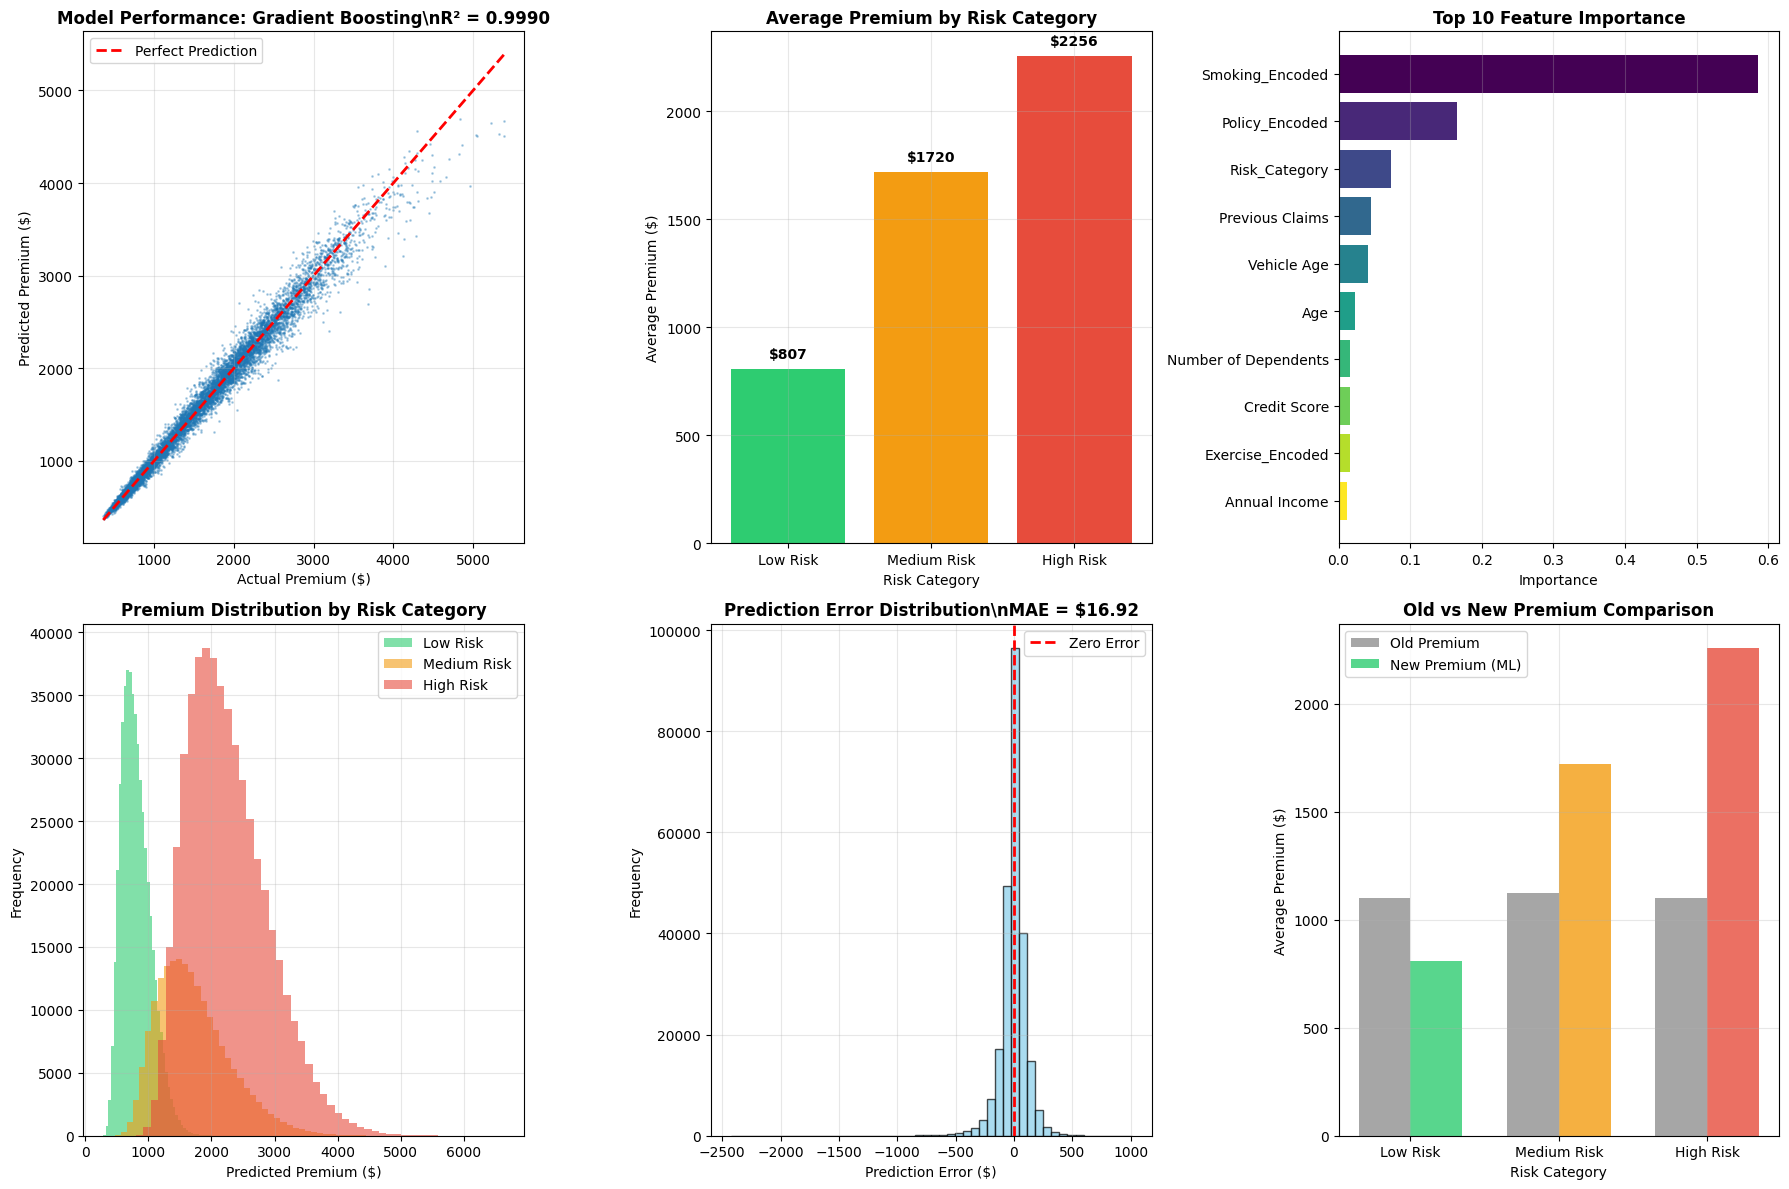

\n[11] Saving models and results...
✓ Models saved: kmeans_model.pkl, scaler.pkl, premium_model.pkl
✓ Sample results saved: premium_predictions_sample.csv (10,000 records)
✓ Summary saved: premium_summary_by_risk.csv
\n================================================================================
✓ STAGE 2 COMPLETE: Premium Prediction Done!
\nModel Performance:
  Best Model: Gradient Boosting
  RMSE: $26.34
  MAE: $16.92
  R²: 0.9990
\n✓ Complete 2-Stage ML Pipeline Finished!
  Stage 1: K-Means Classification → Risk Categories
  Stage 2: Gradient Boosting → Premium Predictions
\n✓ Processed 1,200,000 customers successfully!


In [ ]:
# ============================================================================
# CELL 2: PREMIUM PREDICTION
# ============================================================================

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

print("="*80)
print("STAGE 2: PREMIUM PREDICTION")
print("="*80)

# NOTE: df_work with Risk_Category already exists from Cell 1

# ----------------------------------------------------------------------------
# 1. ENCODE ALL CATEGORICAL FEATURES
# ----------------------------------------------------------------------------
print("\\n[1] Encoding all features for prediction...")

# Gender
df_work['Gender_Encoded'] = (df_work['Gender'] == 'Male').astype(int)

# Marital Status
marital_map = {'Single': 0, 'Married': 1, 'Divorced': 2, 'Widowed': 3}
df_work['Marital_Encoded'] = df_work['Marital Status'].map(
    lambda x: marital_map.get(x, 0) if pd.notna(x) else 0
)

# Education Level
education_map = {'High School': 0, "Bachelor's": 1, "Master's": 2, 'PhD': 3}
df_work['Education_Encoded'] = df_work['Education Level'].map(
    lambda x: education_map.get(x, 1) if pd.notna(x) else 1
)

# Location
location_map = {'Rural': 0, 'Suburban': 1, 'Urban': 2}
df_work['Location_Encoded'] = df_work['Location'].map(
    lambda x: location_map.get(x, 1) if pd.notna(x) else 1
)

# Policy Type
policy_map = {'Basic': 0, 'Comprehensive': 1, 'Premium': 2}
df_work['Policy_Encoded'] = df_work['Policy Type'].map(
    lambda x: policy_map.get(x, 1) if pd.notna(x) else 1
)

# Property Type
property_map = {'Apartment': 0, 'House': 1, 'Condo': 2}
df_work['Property_Encoded'] = df_work['Property Type'].map(
    lambda x: property_map.get(x, 1) if pd.notna(x) else 1
)

# Customer Feedback
feedback_map = {'Poor': 0, 'Average': 1, 'Good': 2, 'Excellent': 3}
df_work['Feedback_Encoded'] = df_work['Customer Feedback'].map(
    lambda x: feedback_map.get(x, 1) if pd.notna(x) else 1
)

print("✓ All features encoded")

# ----------------------------------------------------------------------------
# 2. GENERATE CORRECT PREMIUM LABELS (Training Data)
# ----------------------------------------------------------------------------
print("\\n[2] Generating correct premium labels...")

def calculate_premium(row):
    """Calculate risk-based premium"""
    base_premium = 500
    
    # Risk category multiplier (ensures Low < Medium < High)
    risk_multipliers = {0: 1.0, 1: 1.5, 2: 2.0}
    premium = base_premium * risk_multipliers[row['Risk_Category']]
    
    # Age adjustment
    if row['Age'] < 25:
        premium *= 1.2
    elif row['Age'] > 60:
        premium *= 1.15
    
    # Income adjustment
    if row['Annual Income'] < 20000:
        premium *= 0.9
    elif row['Annual Income'] > 100000:
        premium *= 1.1
    
    # Smoking (major factor)
    if row['Smoking_Encoded'] == 1:
        premium *= 1.4
    
    # Exercise
    premium *= (1 - row['Exercise_Encoded'] * 0.05)
    
    # Health Score
    health_factor = 1 + (100 - row['Health Score']) / 200
    premium *= health_factor
    
    # Previous Claims
    premium *= (1 + row['Previous Claims'] * 0.15)
    
    # Vehicle Age
    premium *= (1 + row['Vehicle Age'] * 0.02)
    
    # Credit Score
    credit_factor = 1 - (row['Credit Score'] - 300) / 1400
    premium *= max(0.8, credit_factor)
    
    # Policy Type
    policy_multiplier = {0: 0.8, 1: 1.0, 2: 1.3}
    premium *= policy_multiplier.get(row['Policy_Encoded'], 1.0)
    
    # Dependents
    premium *= (1 + row['Number of Dependents'] * 0.05)
    
    return round(premium, 2)

# Generate correct premiums (sample for large dataset)
print("   Calculating correct premiums (this may take a moment)...")
df_work['Correct_Premium'] = df_work.apply(calculate_premium, axis=1)
print(f"✓ Generated correct premiums")
print(f"   Range: ${df_work['Correct_Premium'].min():.2f} - ${df_work['Correct_Premium'].max():.2f}")
print(f"   Mean: ${df_work['Correct_Premium'].mean():.2f}")

# ----------------------------------------------------------------------------
# 3. PREPARE FEATURES FOR ML MODEL
# ----------------------------------------------------------------------------
print("\\n[3] Preparing features for ML model...")

# All features including Risk_Category from clustering
prediction_features = [
    'Age', 'Gender_Encoded', 'Annual Income', 'Marital_Encoded',
    'Number of Dependents', 'Education_Encoded', 'Location_Encoded',
    'Health Score', 'Smoking_Encoded', 'Exercise_Encoded',
    'Previous Claims', 'Vehicle Age', 'Credit Score',
    'Insurance Duration', 'Policy_Encoded', 'Property_Encoded',
    'Feedback_Encoded',
    'Risk_Category'  # ← KEY: Risk category from K-Means clustering!
]

X = df_work[prediction_features].copy()
y = df_work['Correct_Premium'].copy()

print(f"✓ Feature matrix: {X.shape}")
print(f"✓ Features include Risk_Category from clustering")
print(f"✓ Total features: {len(prediction_features)}")

# ----------------------------------------------------------------------------
# 4. SPLIT DATA FOR TRAINING
# ----------------------------------------------------------------------------
print("\\n[4] Splitting data for training...")

# With 1.2M records, we can do a proper train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✓ Training set: {len(X_train):,} samples")
print(f"✓ Test set: {len(X_test):,} samples")

# ----------------------------------------------------------------------------
# 5. TRAIN MODELS
# ----------------------------------------------------------------------------
print("\\n[5] Training ML models...")

# Model 1: Random Forest
print("\\n   Training Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=15, 
    min_samples_split=100,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)
print(f"   RMSE: ${rf_rmse:.2f}")
print(f"   MAE:  ${rf_mae:.2f}")
print(f"   R²:   {rf_r2:.4f}")

# Model 2: Gradient Boosting
print("\\n   Training Gradient Boosting...")
gb_model = GradientBoostingRegressor(
    n_estimators=100, 
    max_depth=7, 
    learning_rate=0.1,
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)
print(f"   RMSE: ${gb_rmse:.2f}")
print(f"   MAE:  ${gb_mae:.2f}")
print(f"   R²:   {gb_r2:.4f}")

# Select best model
if rf_rmse < gb_rmse:
    best_model = rf_model
    best_name = "Random Forest"
    best_rmse = rf_rmse
    best_r2 = rf_r2
    best_mae = rf_mae
else:
    best_model = gb_model
    best_name = "Gradient Boosting"
    best_rmse = gb_rmse
    best_r2 = gb_r2
    best_mae = gb_mae

print(f"\\n✓ Best Model: {best_name}")

# ----------------------------------------------------------------------------
# 6. PREDICT ON ALL CUSTOMERS
# ----------------------------------------------------------------------------
print("\\n[6] Predicting premiums for all customers...")
print("   (This may take a moment with 1.2M records...)")

df_work['Predicted_Premium'] = best_model.predict(X)

print("✓ Predictions complete!")

# ----------------------------------------------------------------------------
# 7. COMPARE WITH OLD PREMIUMS
# ----------------------------------------------------------------------------
print("\\n[7] Comparing predictions with old premiums...")

# Sample comparison
print("\\n" + "="*80)
print("PREMIUM PREDICTIONS - SAMPLE (First 10 Customers)")
print("="*80)

sample_df = df_work.head(10)[['id', 'Age', 'Smoking Status', 'Risk_Label', 
                                'Premium Amount', 'Predicted_Premium']].copy()
sample_df.columns = ['ID', 'Age', 'Smoking', 'Risk Category', 
                     'Old Premium', 'NEW Premium (ML)']
sample_df['Change'] = sample_df['NEW Premium (ML)'] - sample_df['Old Premium']
sample_df['Change %'] = (sample_df['Change'] / sample_df['Old Premium'] * 100).round(1)

print("\\n" + sample_df.to_string(index=False))

# Overall statistics
print("\\n" + "="*80)
print("OVERALL PREMIUM STATISTICS")
print("="*80)

print("\\nOld Premiums:")
print(f"   Mean: ${df_work['Premium Amount'].mean():.2f}")
print(f"   Median: ${df_work['Premium Amount'].median():.2f}")
print(f"   Std Dev: ${df_work['Premium Amount'].std():.2f}")

print("\\nNew Predicted Premiums:")
print(f"   Mean: ${df_work['Predicted_Premium'].mean():.2f}")
print(f"   Median: ${df_work['Predicted_Premium'].median():.2f}")
print(f"   Std Dev: ${df_work['Predicted_Premium'].std():.2f}")

# ----------------------------------------------------------------------------
# 8. VERIFY RISK-BASED PRICING
# ----------------------------------------------------------------------------
print("\\n" + "="*80)
print("VERIFICATION: Premium by Risk Category")
print("="*80)

print("\\nAverage Predicted Premiums by Risk:")
premium_by_risk = df_work.groupby('Risk_Label').agg({
    'Predicted_Premium': ['mean', 'median', 'std', 'min', 'max', 'count']
}).round(2)

for risk_label in ['Low Risk', 'Medium Risk', 'High Risk']:
    if risk_label in premium_by_risk.index:
        stats = premium_by_risk.loc[risk_label, 'Predicted_Premium']
        print(f"\\n{risk_label}:")
        print(f"   Count: {int(stats['count']):,}")
        print(f"   Mean: ${stats['mean']:.2f}")
        print(f"   Median: ${stats['median']:.2f}")
        print(f"   Range: ${stats['min']:.2f} - ${stats['max']:.2f}")

# Check ordering
low_avg = df_work[df_work['Risk_Label'] == 'Low Risk']['Predicted_Premium'].mean()
med_avg = df_work[df_work['Risk_Label'] == 'Medium Risk']['Predicted_Premium'].mean()
high_avg = df_work[df_work['Risk_Label'] == 'High Risk']['Predicted_Premium'].mean()

print("\\n" + "-"*80)
if low_avg < med_avg < high_avg:
    print("✓ SUCCESS: Low Risk < Medium Risk < High Risk")
    print(f"   Low: ${low_avg:.2f} < Medium: ${med_avg:.2f} < High: ${high_avg:.2f}")
else:
    print("⚠ WARNING: Premium ordering may need adjustment")
    print(f"   Low: ${low_avg:.2f}, Medium: ${med_avg:.2f}, High: ${high_avg:.2f}")

# ----------------------------------------------------------------------------
# 9. FEATURE IMPORTANCE
# ----------------------------------------------------------------------------
print("\\n" + "="*80)
print("TOP 10 MOST IMPORTANT FEATURES")
print("="*80)

feature_importance = pd.DataFrame({
    'Feature': prediction_features,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\\n" + feature_importance.head(10).to_string(index=False))

# ----------------------------------------------------------------------------
# 10. VISUALIZATIONS
# ----------------------------------------------------------------------------
print("\\n[10] Creating prediction visualizations...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Model Performance (Predicted vs Actual)
ax = axes[0, 0]
# Sample for plotting (too many points to plot all)
sample_indices = np.random.choice(len(X_test), size=min(10000, len(X_test)), replace=False)
y_test_sample = y_test.iloc[sample_indices]
rf_pred_sample = rf_pred[sample_indices]

ax.scatter(y_test_sample, rf_pred_sample, alpha=0.3, s=1)
min_val = min(y_test_sample.min(), rf_pred_sample.min())
max_val = max(y_test_sample.max(), rf_pred_sample.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Premium ($)')
ax.set_ylabel('Predicted Premium ($)')
ax.set_title(f'Model Performance: {best_name}\\nR² = {best_r2:.4f}', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Premium by Risk Category
ax = axes[0, 1]
avg_premiums = df_work.groupby('Risk_Category')['Predicted_Premium'].mean()
ax.bar([0, 1, 2], avg_premiums, color=[risk_colors[i] for i in [0, 1, 2]])
ax.set_xlabel('Risk Category')
ax.set_ylabel('Average Premium ($)')
ax.set_title('Average Premium by Risk Category', fontweight='bold')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels([risk_labels[i] for i in [0, 1, 2]])
for i, v in enumerate(avg_premiums):
    ax.text(i, v + 50, f'${v:.0f}', ha='center', fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 3: Feature Importance (Top 10)
ax = axes[0, 2]
top_10 = feature_importance.head(10)
colors_feat = plt.cm.viridis(np.linspace(0, 1, len(top_10)))
ax.barh(range(len(top_10)), top_10['Importance'], color=colors_feat)
ax.set_yticks(range(len(top_10)))
ax.set_yticklabels(top_10['Feature'])
ax.set_xlabel('Importance')
ax.set_title('Top 10 Feature Importance', fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Plot 4: Premium Distribution by Risk
ax = axes[1, 0]
for risk_cat in [0, 1, 2]:
    data = df_work[df_work['Risk_Category'] == risk_cat]['Predicted_Premium']
    ax.hist(data, bins=50, alpha=0.6, label=risk_labels[risk_cat],
            color=risk_colors[risk_cat])
ax.set_xlabel('Predicted Premium ($)')
ax.set_ylabel('Frequency')
ax.set_title('Premium Distribution by Risk Category', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 5: Prediction Error Distribution
ax = axes[1, 1]
errors = rf_pred - y_test.values
ax.hist(errors, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax.set_xlabel('Prediction Error ($)')
ax.set_ylabel('Frequency')
ax.set_title(f'Prediction Error Distribution\\nMAE = ${best_mae:.2f}', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 6: Old vs New Premium Comparison
ax = axes[1, 2]
old_by_risk = df_work.groupby('Risk_Category')['Premium Amount'].mean()
new_by_risk = df_work.groupby('Risk_Category')['Predicted_Premium'].mean()
x = np.arange(3)
width = 0.35
ax.bar(x - width/2, old_by_risk, width, label='Old Premium', color='gray', alpha=0.7)
ax.bar(x + width/2, new_by_risk, width, label='New Premium (ML)',
       color=[risk_colors[i] for i in [0, 1, 2]], alpha=0.8)
ax.set_xlabel('Risk Category')
ax.set_ylabel('Average Premium ($)')
ax.set_title('Old vs New Premium Comparison', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([risk_labels[i] for i in [0, 1, 2]])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/premium_prediction_results.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved: premium_prediction_results.png")
plt.show()

# ----------------------------------------------------------------------------
# 11. SAVE MODELS AND RESULTS
# ----------------------------------------------------------------------------
print("\\n[11] Saving models and results...")

# Save models
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(best_model, 'premium_model.pkl')
print("✓ Models saved: kmeans_model.pkl, scaler.pkl, premium_model.pkl")

# Save sample results (first 10,000 records)
sample_results = df_work.head(10000)[['id', 'Age', 'Gender', 'Annual Income',
                                       'Health Score', 'Smoking Status', 
                                       'Previous Claims', 'Risk_Label',
                                       'Premium Amount', 'Predicted_Premium']].copy()
sample_results['Premium_Change'] = sample_results['Predicted_Premium'] - sample_results['Premium Amount']
sample_results.to_csv('../data/premium_predictions_sample.csv', index=False)
print("✓ Sample results saved: premium_predictions_sample.csv (10,000 records)")

# Save summary by risk category
risk_summary = df_work.groupby('Risk_Label').agg({
    'id': 'count',
    'Age': 'mean',
    'Health Score': 'mean',
    'Smoking_Encoded': lambda x: (x==1).sum()/len(x)*100,
    'Previous Claims': 'mean',
    'Premium Amount': 'mean',
    'Predicted_Premium': ['mean', 'median', 'std']
}).round(2)
risk_summary.to_csv('premium_summary_by_risk.csv')
print("✓ Summary saved: premium_summary_by_risk.csv")

print("\\n" + "="*80)
print("✓ STAGE 2 COMPLETE: Premium Prediction Done!")
print("="*80)
print(f"\\nModel Performance:")
print(f"  Best Model: {best_name}")
print(f"  RMSE: ${best_rmse:.2f}")
print(f"  MAE: ${best_mae:.2f}")
print(f"  R²: {best_r2:.4f}")
print(f"\\n✓ Complete 2-Stage ML Pipeline Finished!")
print(f"  Stage 1: K-Means Classification → Risk Categories")
print(f"  Stage 2: {best_name} → Premium Predictions")
print(f"\\n✓ Processed {len(df_work):,} customers successfully!")